# Dependencies and Imports

In [1]:
# Install required libraries
!pip install gymnasium highway-env stable-baselines3 torch matplotlib imageio sympy==1.12

# For video rendering
!apt-get install -y ffmpeg

INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:

In [2]:
import gymnasium as gym
import highway_env
from stable_baselines3 import PPO
from tqdm import trange

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

import torch
import imageio
from google.colab import files
from IPython.display import Video

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
gym.register_envs(highway_env)

# Upload Model Zip File Here

In [4]:
uploaded = files.upload()

Saving final_model.zip to final_model.zip


# Verify Model has Low Probability of Failure

In [ ]:
NUM_EPISODES = 100
successes = 0
failures = 0

collision_positions = []  # (x, y) of ego at crash
collision_speeds = []     # ego speed at crash
collision_types = []      # 'merger' or 'highway'

model = PPO.load("final_model.zip")
env = gym.make("merge-v0", render_mode="rgb_array") # Added render_mode
device = model.device

for episode in trange(NUM_EPISODES):
    obs, info = env.reset()
    done = truncated = False
    merger = env.unwrapped.road.vehicles[-1]  # capture reference at reset, before any steps

    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(action)

    vehicle = env.unwrapped.vehicle
    if getattr(vehicle, 'crashed', False):
        failures += 1
        collision_positions.append(vehicle.position.copy())
        collision_speeds.append(vehicle.speed)

        # If merger also crashed, they collided with each other
        hit_merger = merger.crashed
        collision_types.append('merger' if hit_merger else 'highway')
    else:
        successes += 1

env.close()

merger_fails  = collision_types.count('merger')
highway_fails = collision_types.count('highway')
p_fail = failures / NUM_EPISODES

print(f"Successes:      {successes}/{NUM_EPISODES}")
print(f"Failures:       {failures}/{NUM_EPISODES}")
print(f"  Merger:       {merger_fails} ({merger_fails/NUM_EPISODES*100:.2f}%)")
print(f"  Highway:      {highway_fails} ({highway_fails/NUM_EPISODES*100:.2f}%)")
print(f"P(failure) ≈    {p_fail:.4f}  ({p_fail*100:.2f}%)")

  0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
  1%|          | 1/100 [00:01<01:41,  1.03s/it]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC)

Successes:      99/100
Failures:       1/100
  Merger:       0 (0.00%)
  Highway:      1 (1.00%)
P(failure) ≈    0.0100  (1.00%)


# Fuzzing Helper Functions: Run Rollout + Evaluate Proposal

In [6]:
def evaluate_proposal(delay_prob = 0.01, NUM_EPISODES = 100):
    model = PPO.load("final_model.zip")
    env = gym.make("merge-v0", render_mode="rgb_array") # Added render_mode
    device = model.device

    failure_logps = []
    mlf_logp = -np.inf
    mlf_frames = None

    for episode in trange(NUM_EPISODES):
        failed, _, logp, _, frames = run_rollout(env, model, delay_prob)
        if failed:
          failure_logps.append(logp)
          if logp > mlf_logp:
              mlf_logp = logp
              mlf_frames = frames

    env.close()

    return mlf_logp, mlf_frames, failure_logps


In [5]:
def run_rollout(env, model, delay_prob=0.01, nominal_delay_prob=0.01, record_video=True):

    obs, info = env.reset()
    done = truncated = False

    logp_nominal = 0.0
    logp_proposal = 0.0

    frames = []
    prev_action = None

    merger = env.unwrapped.road.vehicles[-1]

    while not (done or truncated):

        if record_video:
            frames.append(env.render())

        intended_action, _ = model.predict(obs, deterministic=True)

        delayed = False

        if prev_action is not None and np.random.rand() < delay_prob:
            action = prev_action
            delayed = True
        else:
            action = intended_action

        # proposal likelihood
        if delayed:
            logp_proposal += np.log(delay_prob)
        else:
            logp_proposal += np.log(1 - delay_prob)

        # nominal likelihood (fixed at 0.01)
        if delayed:
            logp_nominal += np.log(nominal_delay_prob)
        else:
            logp_nominal += np.log(1 - nominal_delay_prob)

        prev_action = action

        obs, reward, done, truncated, info = env.step(action)

    vehicle = env.unwrapped.vehicle

    failed = False
    failure_type = None

    if getattr(vehicle, "crashed", False):
        failed = True
        hit_merger = merger.crashed
        failure_type = "merger" if hit_merger else "highway"

    return failed, failure_type, logp_nominal, logp_proposal, frames

# Fuzzing

In [ ]:
delay_probabilities = np.linspace(0.05, 1.00, 20)
num_rollouts_sweep = 1

action_metrics = {}
all_failure_logps = []
total_rollouts = 0
total_failures = 0

best_logp = -np.inf
best_frames = None
best_delay_prob = None


for delay_prob in delay_probabilities:

    print(f"Testing delay probability {delay_prob:.2f}")

    metric, frames, failure_logps = evaluate_proposal(delay_prob, num_rollouts_sweep)

    action_metrics[delay_prob] = metric
    if len(failure_logps) > 0:
        all_failure_logps.extend(failure_logps)
    total_rollouts += num_rollouts_sweep
    total_failures += len(failure_logps)

    if metric > best_logp:
        best_logp = metric
        best_frames = frames
        best_delay_prob = delay_prob

print("\nTotal Rollouts:", total_rollouts)
print("Total Failures:", total_failures)
print("Highest Failure Likelihood:", best_logp)
print("Correponding Delay Probability:", best_delay_prob)

Testing delay probability 0.05


AttributeError: module 'sympy' has no attribute 'printing'

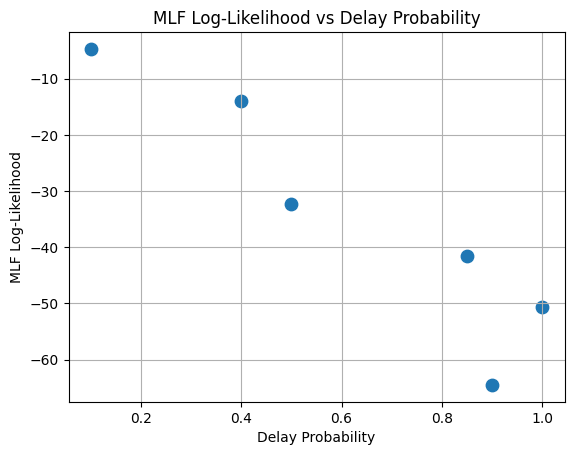

In [ ]:
plt.figure()

plt.scatter(
    list(action_metrics.keys()),
    list(action_metrics.values()),
    s=80
)

plt.title("MLF Log-Likelihood vs Delay Probability")
plt.xlabel("Delay Probability")
plt.ylabel("MLF Log-Likelihood")

plt.grid(True)
plt.show()

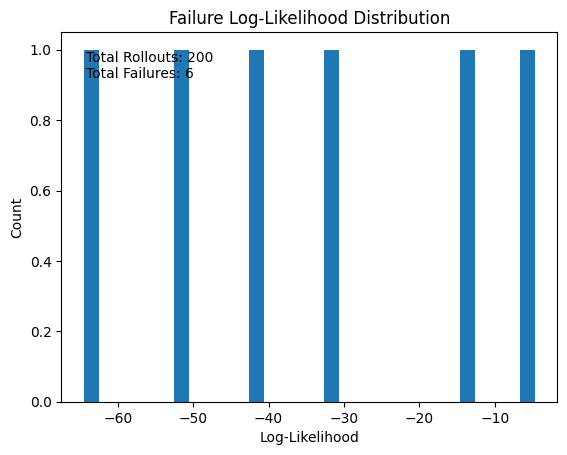

In [ ]:
plt.figure()

plt.hist(all_failure_logps, bins=30)

plt.title("Failure Log-Likelihood Distribution")
plt.xlabel("Log-Likelihood")
plt.ylabel("Count")

plt.text(
    0.05, 0.95,
    f"Total Rollouts: {total_rollouts}\nTotal Failures: {total_failures}",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.show()

In [ ]:
if best_frames is not None:

    imageio.mimsave("most_likely_failure.mp4", best_frames, fps=30)

    print("\nMost Likely Failure Found")
    print("Delay Probability:", best_delay_prob)
    print("Failure Type:", best_failure_type)
    print("Log Likelihood:", best_logp)

else:
    print("No failures occurred during fuzzing.")


Most Likely Failure Found
Delay Probability: 0.1
Failure Type: None
Log Likelihood: -4.705673544523103


In [ ]:
Video("most_likely_failure.mp4", embed=True)

# Importance Sampling

In [ ]:
NUM_ROLLOUTS = 100
delay_prob = 0.08

model = PPO.load("final_model.zip")
env = gym.make("merge-v0", render_mode="rgb_array")

weights = []

pf_estimates = []
ci_lower = []
ci_upper = []

best_logp = -np.inf
best_frames = None

for i in trange(NUM_ROLLOUTS):

    failed, _, logp_nom, logp_prop, frames = run_rollout(
        env,
        model,
        delay_prob
    )

    # importance weight
    if failed:
        w = np.exp(logp_nom - logp_prop)
    else:
        w = 0.0

    weights.append(w)

    weights_np = np.array(weights)

    pf_hat = np.mean(weights_np)
    pf_estimates.append(pf_hat)

    # 95% confidence interval
    if len(weights_np) > 1:
        std = np.std(weights_np, ddof=1)
        ci = 1.96 * std / np.sqrt(len(weights_np))
    else:
        ci = 0

    ci_lower.append(pf_hat - ci)
    ci_upper.append(pf_hat + ci)

    # track most likely failure
    if failed and logp_nom > best_logp:
        best_logp = logp_nom
        best_frames = frames

env.close()

  0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
  1%|          | 1/100 [00:01<02:49,  1.71s/it]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC)

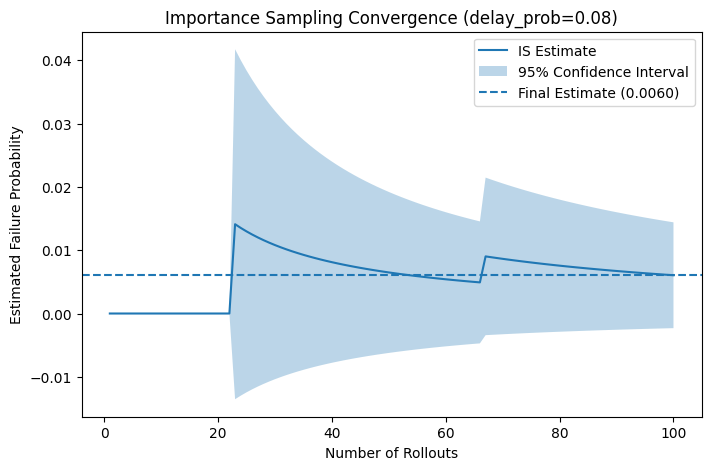

In [ ]:
rollouts = np.arange(1, NUM_ROLLOUTS + 1)

plt.figure(figsize=(8,5))

# running estimate
plt.plot(rollouts, pf_estimates, label="IS Estimate")

# confidence interval
plt.fill_between(
    rollouts,
    ci_lower,
    ci_upper,
    alpha=0.3,
    label="95% Confidence Interval"
)

# final estimate line
plt.axhline(
    pf_estimates[-1],
    linestyle="--",
    label=f"Final Estimate ({pf_estimates[-1]:.4f})"
)

plt.xlabel("Number of Rollouts")
plt.ylabel("Estimated Failure Probability")
plt.title(f"Importance Sampling Convergence (delay_prob={delay_prob})")

plt.legend()
plt.show()

In [ ]:
if best_frames is not None:
    imageio.mimsave("most_likely_failure.mp4", best_frames, fps=30)

# Adaptive Importance Sampling w/Cross-Entropy

In [ ]:
NUM_ITER = 10
ROLLOUTS_PER_ITER = 20

ELITE_FRAC = 0.2

nominal_delay_prob = 0.01

alpha = 2
beta = 20

model = PPO.load("final_model.zip")
env = gym.make("merge-v0", render_mode="rgb_array")

weights = []

pf_estimates = []
ci_lower = []
ci_upper = []

best_logp = -np.inf
best_frames = None

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
for iteration in trange(NUM_ITER):

    delays = []
    scores = []
    iteration_weights = []

    for _ in range(ROLLOUTS_PER_ITER):

        # sample proposal parameter
        delay_prob = np.random.beta(alpha, beta)

        failed, _, logp_nom, logp_prop, frames = run_rollout(
            env,
            model,
            delay_prob,
            nominal_delay_prob
        )

        if failed:
            w = np.exp(logp_nom - logp_prop)
        else:
            w = 0.0

        iteration_weights.append(w)
        weights.append(w)

        # score = nominal likelihood (rare-event objective)
        scores.append(logp_nom)
        delays.append(delay_prob)

        if failed and logp_nom > best_logp:
            best_logp = logp_nom
            best_frames = frames

    # -----------------------
    # Cross entropy update
    # -----------------------

    scores = np.array(scores)
    delays = np.array(delays)

    elite_count = max(1, int(ELITE_FRAC * len(scores)))

    elite_idx = np.argsort(scores)[-elite_count:]

    elite_delays = delays[elite_idx]

    # Fit Beta distribution to elite samples
    mean = np.mean(elite_delays)
    var = np.var(elite_delays) + 1e-6

    temp = mean*(1-mean)/var - 1

    alpha = max(1.0, mean * temp)
    beta = max(1.0, (1-mean) * temp)

    # -----------------------
    # update estimate
    # -----------------------

    weights_np = np.array(weights)

    pf_hat = np.mean(weights_np)
    pf_estimates.append(pf_hat)

    if len(weights_np) > 1:
        std = np.std(weights_np, ddof=1)
        ci = 1.96 * std / np.sqrt(len(weights_np))
    else:
        ci = 0

    ci_lower.append(pf_hat - ci)
    ci_upper.append(pf_hat + ci)

 10%|█         | 1/10 [00:43<06:34, 43.89s/it]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
 20%|██        | 2/10 [01:28<05:56, 44.60s/it]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetim

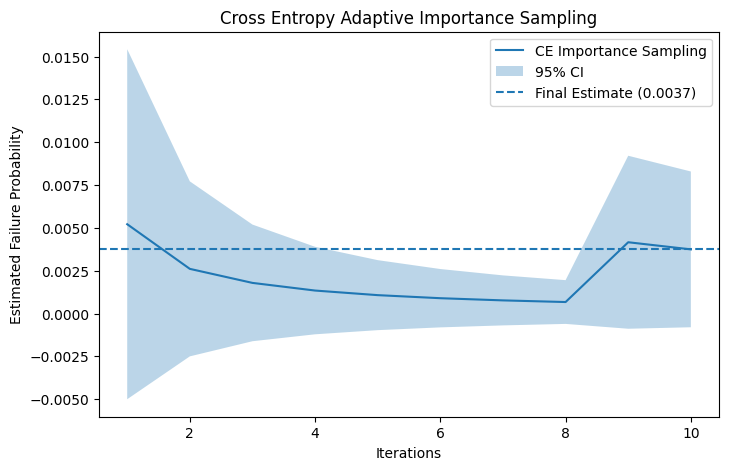

In [ ]:
rollouts = np.arange(1, len(pf_estimates) + 1)

plt.figure(figsize=(8,5))

plt.plot(rollouts, pf_estimates, label="CE Importance Sampling")

plt.fill_between(
    rollouts,
    ci_lower,
    ci_upper,
    alpha=0.3,
    label="95% CI"
)

plt.axhline(
    pf_estimates[-1],
    linestyle="--",
    label=f"Final Estimate ({pf_estimates[-1]:.4f})"
)

plt.xlabel("Iterations")
plt.ylabel("Estimated Failure Probability")
plt.title("Cross Entropy Adaptive Importance Sampling")

plt.legend()
plt.show()

# Most Likely Failure Video Collecting

In [12]:
delay_prob = 0.08
NUM_EPISODES = 10000
threshold = -0.125
best_frames = None
best_mlf_logp = -np.inf

model = PPO.load("final_model.zip")
env = gym.make("merge-v0", render_mode="rgb_array") # Added render_mode
device = model.device

failure_logps = []
mlf_logp = -np.inf
mlf_frames = None

for episode in trange(NUM_EPISODES):
    failed, _, logp, _, frames = run_rollout(env, model, delay_prob)
    if failed and logp > threshold:
        best_frames = frames
        best_mlf_logp = logp
        break

env.close()

  0%|          | 0/10000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
  0%|          | 1/10000 [00:02<5:40:07,  2.04s/it]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetim

In [13]:
if best_frames is not None:
    imageio.mimsave("most_likely_failure.mp4", best_frames, fps=30)

In [14]:
Video("most_likely_failure.mp4", embed=True)

In [15]:
print("Best Delay Failure Likelihood: ", best_mlf_logp)

Best Delay Failure Likelihood:  -0.12060403024201743
